# Determine the Optimal Scale for Main Sample Boundary

This notebook reads in a subsample of 10 mock files generated for each ellipse scaling (s = 2, 2.5, 3, 3.5, 4), and compares the predicted $\eta$ values in each mock to its intrinsic $\eta_{\rm true}$ value based on the DESI DR2 TF Mocks.

In [27]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import cm, colors
from matplotlib.patches import Ellipse
import matplotlib as mpl

colors = plt.colormaps['tab10'].colors
import ligo.skymap.plot

from astropy.table import Table, vstack, join
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
from astropy import constants as c
from astropy.io import fits
from IPython.display import display

from cosmoprimo.fiducial import DESI

from scipy.spatial.distance import cdist, euclidean

import os
from glob import glob

from corner import corner

import pickle

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2
import math

from tqdm import tqdm
from hdbscan import HDBSCAN
from scipy.stats import binned_statistic
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky
from astropy import constants as const

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
# sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/code/TF/')
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import adjust_lightness, profile_histogram
from line_fits import hyperfit_line_multi
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame

In [2]:
# Base values for later conversions (all in units in km/s).
c_kms = c.c.to_value('km/s')

h = 1.
H0 = 100*h

q0 = 0.2

In [3]:
def mean_eta_z(cat_prefix, zbins, n_mocks=10, eta_col='LOGDIST', eta_err_col='LOGDIST_ERR', main='MAIN'):
    eta_list = []  # to store each mock's binned mean
    
    for i in range(n_mocks):
        # Get the catalog variable from globals()
        cat = globals()[f"{cat_prefix}_{i}"]
        
        # Apply profile_histogram for this mock
        _, eta_avg, _ = profile_histogram(
            cat['ZOBS'][cat[main]],
            cat[eta_col][cat[main]],
            zbins,
            weights=cat[eta_err_col][cat[main]]**-2,
            weighted=True
        )
        
        eta_list.append(eta_avg)
    
    # Stack all mock results into a 2D array: shape (n_mocks, n_bins)
    eta_array = np.vstack(eta_list)
    
    # Compute mean and std across mocks (axis=0 → across rows)
    eta_mean = np.mean(eta_array, axis=0)
    eta_std = np.std(eta_array, axis=0)
    
    # Compute bin centers
    zc = 0.5 * (zbins[1:] + zbins[:-1])
    
    return zc, eta_mean, eta_std

def mean_eta_eta(cat_prefix, eta_bins, n_mocks=10, eta_col='LOGDIST', eta_err_col='LOGDIST_ERR', main='MAIN'):
    eta_list = []  # to store each mock's binned mean
    
    for i in range(n_mocks):
        # Get the catalog variable from globals()
        cat = globals()[f"{cat_prefix}_{i}"]
        
        _, eta_avg, _ = profile_histogram(
            cat['LOGDIST_TRUE'][cat[main]],
            cat[eta_col][cat[main]],
            eta_bins,
            # stat='median',
            weights=cat[eta_err_col][cat[main]]**-2,
            weighted=True
        )
        
        eta_list.append(eta_avg)
    
    # Stack all mock results into a 2D array: shape (n_mocks, n_bins)
    eta_array = np.vstack(eta_list)
    
    # Compute mean and std across mocks (axis=0 → across rows)
    eta_mean = np.mean(eta_array, axis=0)
    eta_std = np.std(eta_array, axis=0)
    
    # Compute bin centers
    eta_c = 0.5 * (eta_bins[1:] + eta_bins[:-1])
    
    return eta_c, eta_mean, eta_std

def mean_delta_eta_z(cat_prefix, zbins, n_mocks=10, eta_col='LOGDIST', eta_err_col='LOGDIST_ERR', main='MAIN'):
    eta_list = []  # to store each mock's binned mean
    
    for i in range(n_mocks):
        # Get the catalog variable from globals()
        cat = globals()[f"{cat_prefix}_{i}"]

        _, eta_avg, _ = profile_histogram(
            cat['ZOBS'][cat[main]],
            cat[eta_col][cat[main]] - cat['LOGDIST_TRUE'][cat[main]],
            zbins,
            # stat='median'
            weights=cat[eta_err_col][cat[main]]**-2,
            weighted=True
        )
        
        eta_list.append(eta_avg)
    
    # Stack all mock results into a 2D array: shape (n_mocks, n_bins)
    eta_array = np.vstack(eta_list)
    
    # Compute mean and std across mocks (axis=0 → across rows)
    eta_mean = np.mean(eta_array, axis=0)
    eta_std = np.std(eta_array, axis=0)
    
    # Compute bin centers
    zc = 0.5 * (zbins[1:] + zbins[:-1])
    
    return zc, eta_mean, eta_std


def mean_delta_eta_m(cat_prefix, mbins, n_mocks=10, eta_col='LOGDIST', eta_err_col='LOGDIST_ERR', main='MAIN'):
    eta_list = []  # to store each mock's binned mean
    
    for i in range(n_mocks):
        # Get the catalog variable from globals()
        cat = globals()[f"{cat_prefix}_{i}"]

        _, eta_avg, _ = profile_histogram(
            cat['R_ABSMAG_SB26'][cat[main]],
            cat[eta_col][cat[main]] - cat['LOGDIST_TRUE'][cat[main]],
            mbins,
            weights=cat[eta_err_col][cat[main]]**-2,
            weighted=True
        )
        
        eta_list.append(eta_avg)
    
    # Stack all mock results into a 2D array: shape (n_mocks, n_bins)
    eta_array = np.vstack(eta_list)
    
    # Compute mean and std across mocks (axis=0 → across rows)
    eta_mean = np.mean(eta_array, axis=0)
    eta_std = np.std(eta_array, axis=0)
    
    # Compute bin centers
    mc = 0.5 * (mbins[1:] + mbins[:-1])
    
    return mc, eta_mean, eta_std

def mean_delta_eta_appm(cat_prefix, mbins, n_mocks=10, eta_col='LOGDIST', eta_err_col='LOGDIST_ERR', main='MAIN'):
    eta_list = []  # to store each mock's binned mean
    cosmology = FlatLambdaCDM(H0=100*h, Om0=0.3151)
    for i in range(n_mocks):
        # Get the catalog variable from globals()
        cat = globals()[f"{cat_prefix}_{i}"]


        app_m = cosmology.distmod(cat['ZOBS'][cat[main]]).to_value('mag') + cat['R_ABSMAG_SB26'][cat[main]]
        _, eta_avg, _ = profile_histogram(
            app_m,
            cat[eta_col][cat[main]] - cat['LOGDIST_TRUE'][cat[main]],
            mbins,
            weights=cat[eta_err_col][cat[main]]**-2,
            weighted=True
        )
        
        eta_list.append(eta_avg)
    
    # Stack all mock results into a 2D array: shape (n_mocks, n_bins)
    eta_array = np.vstack(eta_list)
    
    # Compute mean and std across mocks (axis=0 → across rows)
    eta_mean = np.mean(eta_array, axis=0)
    eta_std = np.std(eta_array, axis=0)
    
    # Compute bin centers
    mc = 0.5 * (mbins[1:] + mbins[:-1])
    
    return mc, eta_mean, eta_std

def mean_eta_eta_zbins(cat_prefix, eta_bins, n_mocks=10, eta_col='LOGDIST', eta_err_col='LOGDIST_ERR', zmin=0, zmax=1, main='MAIN'):
    eta_list = []  # to store each mock's binned mean
    
    for i in range(n_mocks):
        # Get the catalog variable from globals()
        cat = globals()[f"{cat_prefix}_{i}"]
        cat = cat[(cat['ZOBS'] > zmin) & (cat['ZOBS'] < zmax)]
        _, eta_avg, _ = profile_histogram(
            cat['LOGDIST_TRUE'][cat[main]],
            cat[eta_col][cat[main]],
            eta_bins,
            stat='median'
        )
        
        eta_list.append(eta_avg)
    
    # Stack all mock results into a 2D array: shape (n_mocks, n_bins)
    eta_array = np.vstack(eta_list)
    
    # Compute mean and std across mocks (axis=0 → across rows)
    eta_mean = np.mean(eta_array, axis=0)
    eta_std = np.std(eta_array, axis=0)
    
    # Compute bin centers
    eta_c = 0.5 * (eta_bins[1:] + eta_bins[:-1])
    
    return eta_c, eta_mean, eta_std


def mean_delta_eta_v(cat_prefix, zbins, n_mocks=10, eta_col='LOGDIST', eta_err_col='LOGDIST_ERR', main='MAIN'):
    eta_list = []  # to store each mock's binned mean
    
    for i in range(n_mocks):
        # Get the catalog variable from globals()
        cat = globals()[f"{cat_prefix}_{i}"]

        _, eta_avg, _ = profile_histogram(
            cat['LOGVROT'][cat[main]],
            cat[eta_col][cat[main]] - cat['LOGDIST_TRUE'][cat[main]],
            zbins,
            # stat='median'
            weights=cat[eta_err_col][cat[main]]**-2,
            weighted=True
        )
        
        eta_list.append(eta_avg)
    
    # Stack all mock results into a 2D array: shape (n_mocks, n_bins)
    eta_array = np.vstack(eta_list)
    
    # Compute mean and std across mocks (axis=0 → across rows)
    eta_mean = np.mean(eta_array, axis=0)
    eta_std = np.std(eta_array, axis=0)
    
    # Compute bin centers
    zc = 0.5 * (zbins[1:] + zbins[:-1])
    
    return zc, eta_mean, eta_std

# Calculate $\chi^2$ fits for different ellipse scales

In [5]:
##### Read in all of the mock files

version='v0.5.6'
# for i in range(1):
for i in range(10):
    for scale in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
    # for scale in {2.5}:
        globals()[f'mock_scale{int(scale*10)}_{i}'] = Table.read(f'/pscratch/sd/s/sgmoore1/TF/DR2_mocks/{version}/loa_mock_test_base_c000_ph00{int(i)}_r000_scale_{int(100*scale)}.fits')

In [7]:
mock_scale25_0[:5]

RA,DEC,ZOBS,ZCOS,vx,vy,vz,DWARF,MAIN,LOGVROT,LOGVROT_ERR,R_ABSMAG_SB26,R_ABSMAG_SB26_ERR,R_ABSMAG_SB26_TRUE,LOGDIST_TRUE,LOGDIST,LOGDIST_ERR,Y1_COMP,Y3_COMP
float64,float64,float64,float64,float64,float64,float64,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
183.3409832747839,0.37112814971153024,0.10759354912802443,0.10902369186841486,399.2755432128906,-249.90367126464844,-397.1897888183594,True,False,2.490150246696334,0.018088823598207526,-21.898226130407636,0.04480075858299696,-21.92892307965436,-0.006139389849344923,-0.12228955597528995,0.08196478054787408,0.9876543209876543,0.9876543209876543
186.60654855358175,-3.679901254843868,0.10802724527946217,0.1097609033487355,537.7064819335938,-483.61260986328125,-142.97434997558594,False,True,2.266612695036822,0.022750104073210414,-20.88877069839543,0.03655624302128753,-20.92579368225522,-0.007404596771958438,-0.0032733887948737106,0.08230646787100299,0.96875,1.0
188.98157213450054,4.692266256003652,0.10811560326473013,0.10947197273511843,422.3069152832031,-435.4427490234375,-226.49703979492188,False,True,2.408209048372961,0.02298158612785595,-21.02093505939375,0.07291328234768395,-21.049925875641073,-0.0057981632494644945,-0.18011417924881387,0.08324025180754216,0.954248366013072,0.9869281045751634
182.60903714123236,-5.202646272232211,0.10716526814692684,0.1083549547907323,352.6307373046875,-365.0213928222656,-137.5741729736328,False,True,2.2637936486851418,0.02511989909709657,-21.312228015098057,0.06120100226621497,-21.337886378062095,-0.005131672592807491,0.08546505643180212,0.0832549125494824,0.35877862595419846,0.9923664122137404
171.23327529271236,-3.496748690968217,0.10746735470701596,0.10917725700326764,388.4230651855469,-266.9434509277344,629.2400512695312,False,True,2.223661766685147,0.035728958713394064,-21.018950007994725,0.03802203713391919,-21.0556476233415,-0.007339523069354925,0.08442220033343376,0.08399997764841616,0.9824561403508771,0.9824561403508771


In [8]:
def chi2(cat):
    pull = (cat['LOGDIST'] - cat['LOGDIST_TRUE'])/cat['LOGDIST_ERR']
    chi_squared = np.sum(pull**2)
    # reduced_chi2 = chi_squared/len(cat)
    return chi_squared

def chi2_main(cat):
    pull = (cat['LOGDIST'][cat['MAIN']] - cat['LOGDIST_TRUE'][cat['MAIN']])/cat['LOGDIST_ERR'][cat['MAIN']]
    chi_squared = np.sum(pull**2)
    # reduced_chi2 = chi_squared/np.sum(cat['MAIN'])
    return chi_squared

In [9]:
n_mocks=10
scale = []
chi2_vals = []
reduced_chi2_vals = []
chi2_vals_main = []
reduced_chi2_vals_main = []
i_val = []

for i in range(n_mocks):
    for sig in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
        i_val.append(i)
        cat = globals()[f"mock_scale{int(sig*10)}_{i}"]
        scale.append(sig)
        chi2_vals.append(chi2(cat))
        reduced_chi2_vals.append(chi2(cat)/len(cat))
        chi2_vals_main.append(chi2_main(cat))
        reduced_chi2_vals_main.append(chi2_main(cat)/np.sum(cat['MAIN']))


In [11]:
scale2 =[]
reduced_val=[]
reduced_val_err=[]
for sig in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
    scale2.append(sig)
    chi2s = []
    for i in range(n_mocks):
        cat = globals()[f"mock_scale{int(sig*10)}_{i}"]
        # scale2.append(sig)
        # chi2s.append(chi2(cat))
        # reduced_chi2_vals.append(chi2(cat)/len(cat))
        # chi2_vals_main.append(chi2_main(cat))
        chi2s.append(chi2_main(cat)/np.sum(cat['MAIN']))
    reduced_val.append(np.mean(chi2s))
    reduced_val_err.append(np.std(chi2s))

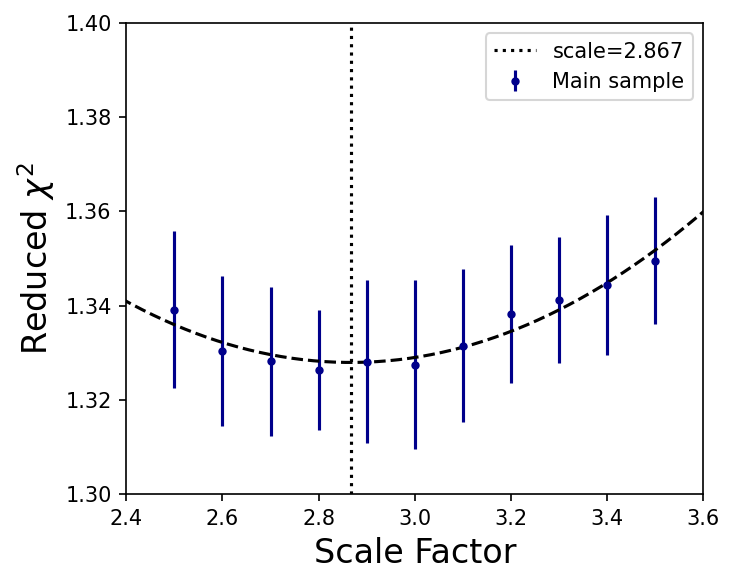

In [17]:
x = scale2
y = reduced_val
yerr = reduced_val_err

# quadratic fit
a, b, c = np.polyfit(x, y, 2)

# minimum (vertex of parabola)
x_min = -b / (2*a)
y_min = a*x_min**2 + b*x_min + c

# smooth curve
# x_fit = np.linspace(2.4, 3.6, 100)
x_fit = np.linspace(1.9, 4.1, 100)
y_fit = np.polyval([a, b, c], x_fit)

# plot
plt.figure(figsize=(5,4), facecolor='none', dpi=150)
plt.axvline(x_min, label=f'scale={x_min:.3f}', color='k', ls='dotted')
plt.errorbar(x, y, yerr=yerr, label='Main sample', fmt='.', color='darkblue')
plt.plot(x_fit, y_fit, 'k--',)

# plt.xlabel('Scale Factor', fontsize=16)
# plt.ylabel(r'Reduced $\chi^2$', fontsize=16)
# plt.ylim(0,2)
# plt.legend()
# plt.show()

# plt.axvline(x_min, label=f'scale={x_min:.2f}', color='k', ls='dotted')
# plt.scatter(x, y, label='Main sample', c=i_val)
# plt.plot(x_fit, y_fit, 'k--',)
# plt.grid(ls=':')
plt.xlabel('Scale Factor', fontsize=16)
plt.ylabel(r'Reduced $\chi^2$', fontsize=16)
plt.xlim(2.4,3.6)
plt.ylim(1.3,1.4)
plt.legend()
plt.tight_layout()
# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_bin_ellipse_chi2.png', 
#             dpi=150, 
#             facecolor='none')

In [18]:
chi2_tab = Table([scale, chi2_vals, reduced_chi2_vals, chi2_vals_main, reduced_chi2_vals_main],
    names=['SCALE','CHI2', 'REDUCED_CHI2', 'CHI2_MAIN', 'REDUCED_CHI2_MAIN'])

In [19]:
chi2_tab

SCALE,CHI2,REDUCED_CHI2,CHI2_MAIN,REDUCED_CHI2_MAIN
float64,float64,float64,float64,float64
2.9,499895.8698997319,2.8446328799925564,214231.50658443378,1.3348921811524606
2.5,571290.9446352111,3.2509030440225293,203002.378051906,1.3532679909332508
2.6,539346.8037223199,3.069126480071016,204777.3724846622,1.335934425541232
2.8,513024.571116378,2.919341109048261,211355.26711331637,1.331749265072407
2.7,527918.2807023039,3.0040930314869936,206440.71493420127,1.321897387041053
3.0,484961.16973695176,2.7596477026907396,215565.65707701983,1.3299215682558336
3.1,476749.79644552217,2.7129212865285526,220475.9500999022,1.350202706211011
3.2,462819.96394048154,2.6336542592483,220893.1202539554,1.344474459387301
3.3,454767.3589548997,2.5878313063277796,221188.7982237755,1.3402944811475217


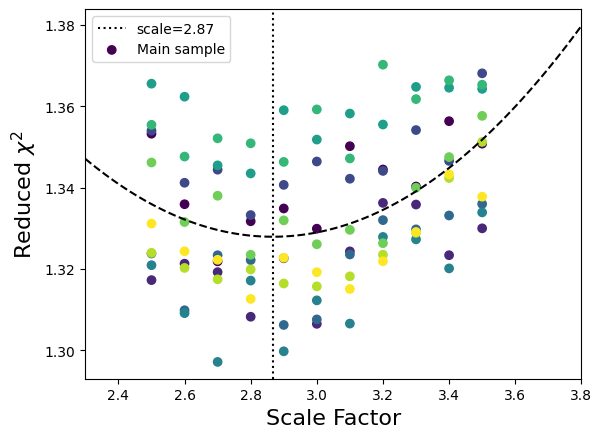

In [20]:
x = chi2_tab['SCALE']
y = chi2_tab['REDUCED_CHI2_MAIN']

# quadratic fit
a, b, c = np.polyfit(x, y, 2)

# minimum (vertex of parabola)
x_min = -b / (2*a)
y_min = a*x_min**2 + b*x_min + c

# smooth curve
x_fit = np.linspace(2.3, 3.8, 100)
y_fit = np.polyval([a, b, c], x_fit)

# plot
plt.axvline(x_min, label=f'scale={x_min:.2f}', color='k', ls='dotted')
plt.scatter(x, y, label='Main sample', c=i_val)
plt.plot(x_fit, y_fit, 'k--',)

# plt.xlabel('Scale Factor', fontsize=16)
# plt.ylabel(r'Reduced $\chi^2$', fontsize=16)
# plt.ylim(0,2)
# plt.legend()
# plt.show()

# plt.axvline(x_min, label=f'scale={x_min:.2f}', color='k', ls='dotted')
# plt.scatter(x, y, label='Main sample', c=i_val)
# plt.plot(x_fit, y_fit, 'k--',)

plt.xlabel('Scale Factor', fontsize=16)
plt.ylabel(r'Reduced $\chi^2$', fontsize=16)
plt.xlim(2.3,3.8)
# plt.ylim(1.3,1.5)
plt.legend()

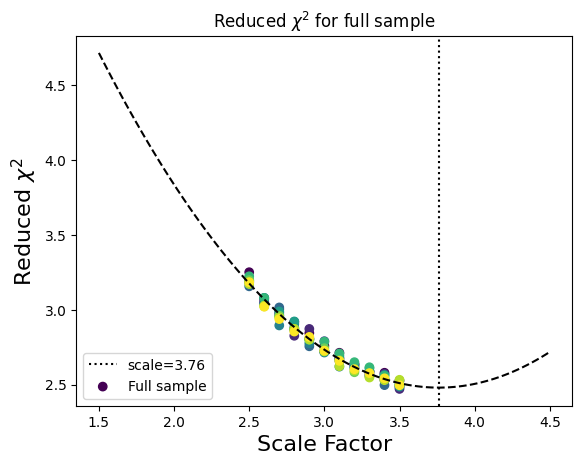

In [21]:
x = chi2_tab['SCALE']
y = chi2_tab['REDUCED_CHI2']

# quadratic fit
a, b, c = np.polyfit(x, y, 2)

# minimum (vertex of parabola)
x_min = -b / (2*a)
y_min = a*x_min**2 + b*x_min + c

# smooth curve
x_fit = np.linspace(1.5, 4.5, 100)
y_fit = np.polyval([a, b, c], x_fit)

# plot
plt.axvline(x_min, label=f'scale={x_min:.2f}', color='k', ls='dotted')
plt.scatter(x, y, label='Full sample', c=i_val)
plt.plot(x_fit, y_fit, 'k--',)

plt.xlabel('Scale Factor', fontsize=16)
plt.ylabel(r'Reduced $\chi^2$', fontsize=16)
plt.legend()
plt.title('Reduced $\chi^2$ for full sample')
plt.show()

/global/u1/s/sgmoore1/DESI_SGA/TF/help_functions.py:62: RuntimeWarning: invalid value encountered in divide
  h = H/W
/global/u1/s/sgmoore1/DESI_SGA/TF/help_functions.py:63: RuntimeWarning: divide by zero encountered in divide
  e = 1/np.sqrt(W)


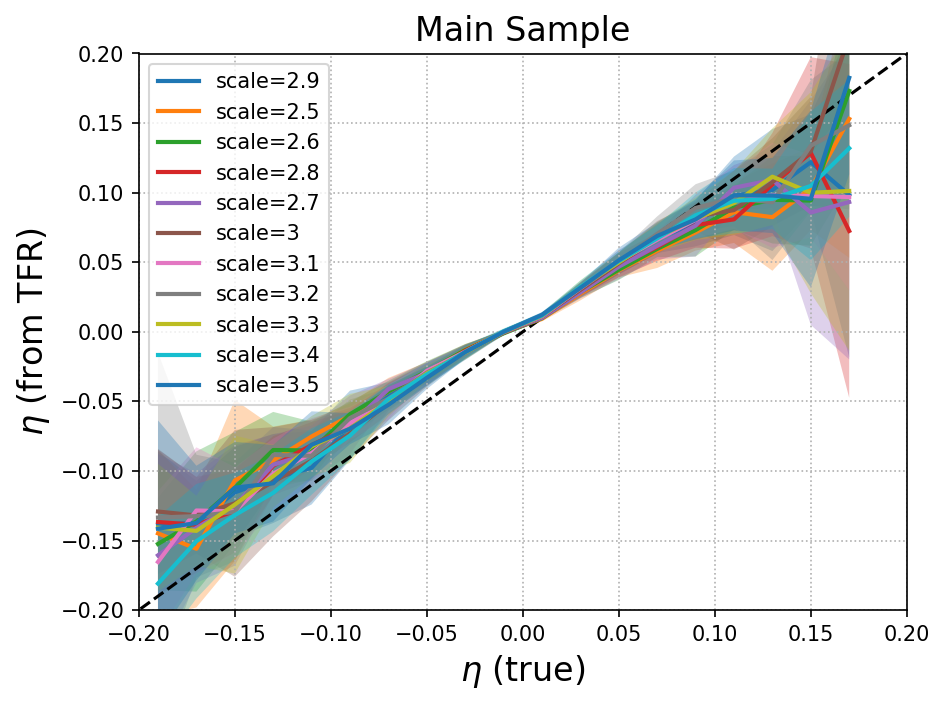

In [22]:
plt.figure(tight_layout=True, dpi=150, facecolor='none')
plt.plot([-5, 2], [-5, 2], '--', c='k')

eta_bins = np.arange(-0.5, 0.3, 0.02)
d_eta = 0.5*np.diff(eta_bins)
eta_c = 0.5*(eta_bins[1:] + eta_bins[:-1])

for i in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
    eta_c, eta_mean, eta_std = mean_eta_eta(f'mock_scale{int(10*i)}', eta_bins, n_mocks=10)
    plt.plot(eta_c, eta_mean, lw=2, label=f'scale={i}')
    plt.fill_between(eta_c, eta_mean - eta_std, eta_mean + eta_std, alpha=0.3)


plt.grid(ls=':')

plt.xlim([-0.2, 0.2])
plt.ylim([-0.2, 0.2])
plt.legend()
plt.title('Main Sample', fontsize=16)
plt.xlabel(r'$\eta$ (true)', fontsize=16)
plt.ylabel(r'$\eta$ (from TFR)', fontsize=16);

# plt.figure(tight_layout=True, dpi=150, facecolor='none')
# plt.plot([-5, 2], [-5, 2], '--', c='k')

# # eta_bins = np.arange(-0.5, 0.3, 0.02)
# # d_eta = 0.5*np.diff(eta_bins)
# # eta_c = 0.5*(eta_bins[1:] + eta_bins[:-1])

# # for i in {2,2.5,3,3.5,4}:
# #     eta_c, eta_mean, eta_std = mean_eta_eta(f'mock_scale{int(10*i)}', eta_bins, n_mocks=10, main='ALL')
# #     plt.plot(eta_c, eta_mean, lw=2, label=f'scale={i}')
# #     plt.fill_between(eta_c, eta_mean - eta_std, eta_mean + eta_std, alpha=0.3)


# plt.grid(ls=':')

# plt.xlim([-0.2, 0.2])
# plt.ylim([-0.2, 0.2])
# plt.legend()
# plt.title('Full Sample', fontsize=16)
# plt.xlabel(r'$\eta$ (true)', fontsize=16)
# plt.ylabel(r'$\eta$ (from TFR)', fontsize=16);

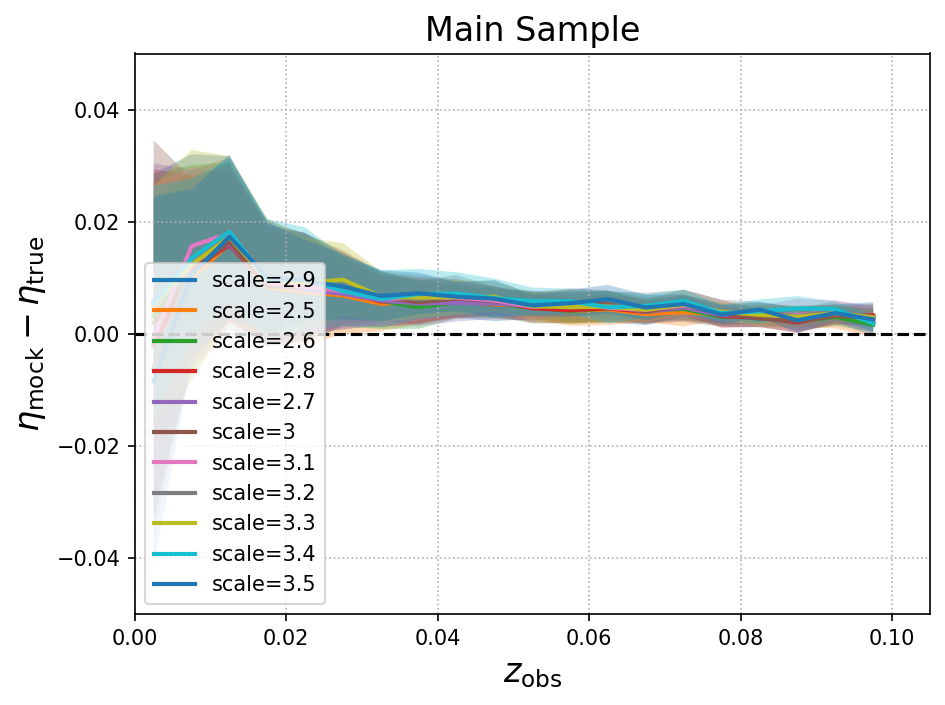

In [23]:
fig = plt.figure(tight_layout=True, facecolor='none', dpi=150)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])

plt.grid(ls=':')

# zc, eta_mean, eta_std = mean_delta_eta_z('mock_sig20_v5b_extrap', n_mocks=10, zbins=_zbins)
# plt.plot(zc, eta_mean, lw=2, color='tab:blue', label='HDBScan ellipse, scale=2, extrap')
# plt.fill_between(zc, eta_mean - eta_std, eta_mean + eta_std, color='tab:blue', alpha=0.3)

for i in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
    zc, eta_mean, eta_std = mean_delta_eta_z(f'mock_scale{int(10*i)}', n_mocks=10, zbins=_zbins)
    plt.plot(zc, eta_mean, lw=2, label=f'scale={i}')
    plt.fill_between(zc, eta_mean - eta_std, eta_mean + eta_std, alpha=0.3)

# Line at delta eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

plt.legend()
plt.title('Main Sample', fontsize=16)
plt.xlabel(r'$z_\mathrm{obs}$', fontsize=16)
plt.ylabel(r'$\eta_{\mathrm{mock}} - \eta_{\mathrm{true}} $', fontsize=16)
plt.xlim(0,0.105)
plt.ylim(-0.05, 0.05);

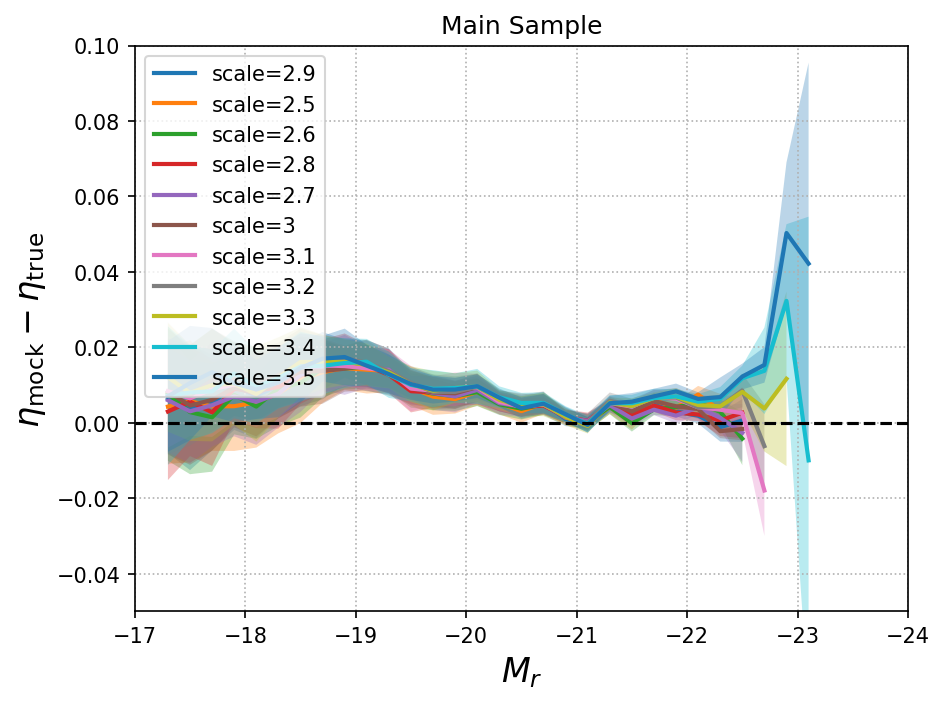

In [24]:
fig = plt.figure(tight_layout=True, facecolor='none', dpi=150)

Mr_bins = np.arange(-24, -17, 0.2)
dMr = 0.5*np.diff(Mr_bins)
Mrc = 0.5*(Mr_bins[1:] + Mr_bins[:-1])

cosmology = FlatLambdaCDM(H0=100*h, Om0=0.3151)
plt.grid(ls=':')


for i in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
    mc, eta_mean, eta_std = mean_delta_eta_m(f'mock_scale{int(10*i)}', Mr_bins, n_mocks=10)
    plt.plot(mc, eta_mean, lw=2, label=f'scale={i}')
    plt.fill_between(mc, eta_mean - eta_std, eta_mean + eta_std, alpha=0.3)


# Line at eta = 0
plt.hlines(0, -24, -17, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend(loc='upper left')
plt.title('Main Sample')
plt.xlabel(r'$M_r$', fontsize=16)
plt.ylabel(r'$\eta_{\mathrm{mock}} - \eta_{\mathrm{true}} $', fontsize=16)
plt.xlim(-17,-24)
plt.ylim(-0.05,0.1)
plt.show()

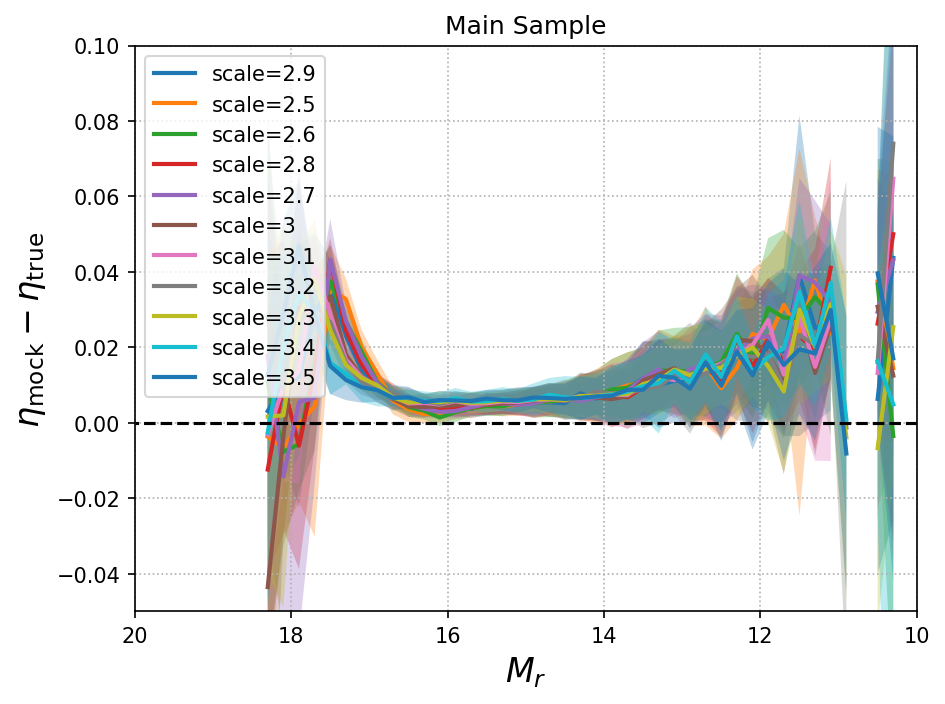

In [25]:
fig = plt.figure(tight_layout=True, facecolor='none', dpi=150)

Mr_bins = np.arange(10,20, 0.2)
dMr = 0.5*np.diff(Mr_bins)
Mrc = 0.5*(Mr_bins[1:] + Mr_bins[:-1])

cosmology = FlatLambdaCDM(H0=100*h, Om0=0.3151)
plt.grid(ls=':')

for i in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
    mc, eta_mean, eta_std = mean_delta_eta_appm(f'mock_scale{int(10*i)}', Mr_bins, n_mocks=10)
    plt.plot(mc, eta_mean, lw=2, label=f'scale={i}')
    plt.fill_between(mc, eta_mean - eta_std, eta_mean + eta_std, alpha=0.3)


# Line at eta = 0

# Line at eta = 0
plt.hlines(0, 10, 20, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend(loc='upper left')
plt.title('Main Sample')
plt.xlabel(r'$M_r$', fontsize=16)
plt.ylabel(r'$\eta_{\mathrm{mock}} - \eta_{\mathrm{true}} $', fontsize=16)
plt.xlim(20,10)
plt.ylim(-0.05,0.1)
plt.show()

Text(0, 0.5, '$\\eta_{\\mathrm{mock}} - \\eta_{\\mathrm{true}} $')

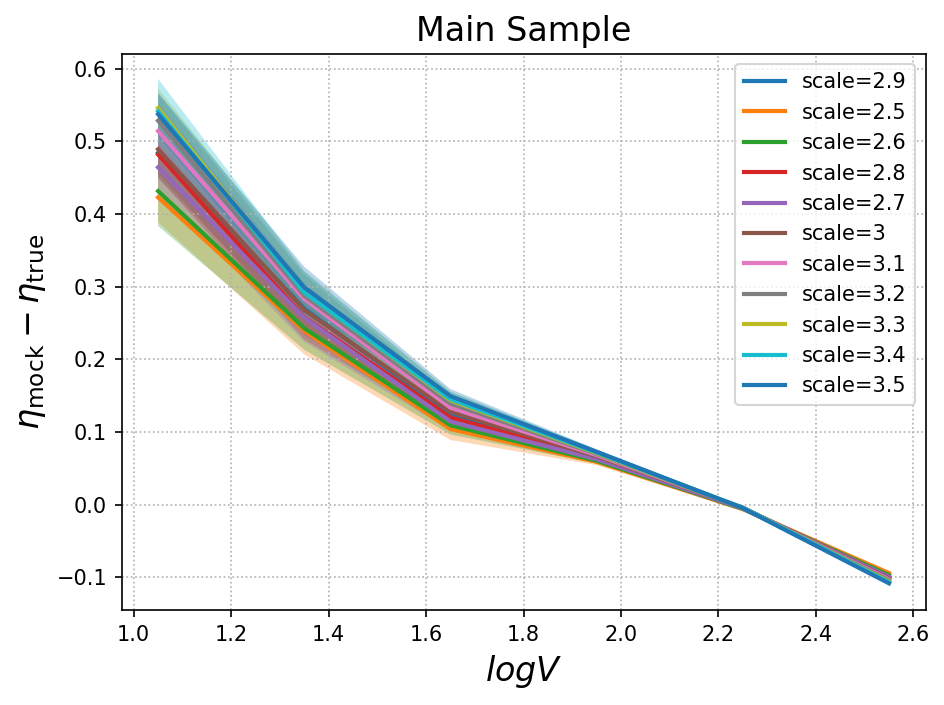

In [26]:
fig = plt.figure(tight_layout=True, facecolor='none', dpi=150)

_zbins = np.arange(0, 3, 0.3)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])

plt.grid(ls=':')

# zc, eta_mean, eta_std = mean_delta_eta_z('mock_sig20_v5b_extrap', n_mocks=10, zbins=_zbins)
# plt.plot(zc, eta_mean, lw=2, color='tab:blue', label='HDBScan ellipse, scale=2, extrap')
# plt.fill_between(zc, eta_mean - eta_std, eta_mean + eta_std, color='tab:blue', alpha=0.3)

for i in {2.5,2.6,2.7,2.8,2.9,3,3.1,3.2,3.3,3.4,3.5}:
    zc, eta_mean, eta_std = mean_delta_eta_v(f'mock_scale{int(10*i)}', n_mocks=10, zbins=_zbins)
    plt.plot(zc, eta_mean, lw=2, label=f'scale={i}')
    plt.fill_between(zc, eta_mean - eta_std, eta_mean + eta_std, alpha=0.3)

# Line at delta eta = 0
# plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

plt.legend()
plt.title('Main Sample', fontsize=16)
plt.xlabel(r'$log V$', fontsize=16)
plt.ylabel(r'$\eta_{\mathrm{mock}} - \eta_{\mathrm{true}} $', fontsize=16)
# plt.xlim(0,0.105)
# plt.ylim(-0.05, 0.05);